In [2]:
!pip install nltk
import nltk 
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nltk]6/7 [nltk]b]


[nltk_data] Downloading package punkt to /Users/vishnusai/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vishnusai/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vishnusai/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vishnusai/nltk_data...


True

In [6]:
!pip install numpy 
!pip install pandas
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 7.1 MB/s  0:00:01eta 0:00:01
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 14.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 13.0 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [9]:
import numpy as np 
import pandas as pd 
import sklearn
from sklearn.datasets import fetch_20newsgroups 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
import re 
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.model_selection import train_test_split


In [14]:
p_spam = 3000 / 10000
p_ham = 7000/ 10000 
word_probs_spam = {'get': 900/ 10000, 'free': 1200/ 10000, 'money': 1100/10000, 'now': 800/ 10000}
word_probs_ham = {'get': 150/ 10000, 'free': 70/ 10000, 'money': 60/10000, 'now': 100/ 10000} 
#calculate probability propotional to spam and ham 
p_sms_givem_spam = p_spam 
for word in ['get', 'free', 'money', 'now']:
    p_sms_givem_spam *= word_probs_spam[word]
p_sms_given_ham = p_ham 
for word in ['get', 'free', 'money', 'now']:
    p_sms_given_ham *= word_probs_ham[word]
print(f"Probability of SMS being spam:{ p_sms_givem_spam:.10f}")
print(f"Probability of SMS being ham:{ p_sms_given_ham:.10f}") 
print("Prediction:", "spam" if p_sms_givem_spam > p_sms_given_ham else "Ham")


Probability of SMS being spam:0.0000285120
Probability of SMS being ham:0.0000000044
Prediction: spam


# sample email dataset

In [15]:
data = {
    'text': [
        "Free money now!!!",
        "Hi Bob, how about a game tomorrow?",
        "Earn cash fast, click here!",
        "Are we meeting today for dinner?",
        "Limited offer, get free coupons!",
        "Don't forget the meeting at 10 am"
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']
} 
df = pd.DataFrame(data)
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    tokens = word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(lemmas)
df['processed'] = df['text'].apply(preprocess)
print(df[['text', 'processed', 'label']])


                                 text                             processed  \
0                   Free money now!!!                  free money now ! ! !   
1  Hi Bob, how about a game tomorrow?  hi bob , how about a game tomorrow ?   
2         Earn cash fast, click here!         earn cash fast , click here !   
3    Are we meeting today for dinner?     are we meeting today for dinner ?   
4    Limited offer, get free coupons!     limited offer , get free coupon !   
5   Don't forget the meeting at 10 am    do n't forget the meeting at 10 am   

  label  
0  spam  
1   ham  
2  spam  
3   ham  
4  spam  
5   ham  


# TF-IDF

In [18]:
vectorizer = TfidfVectorizer(ngram_range= (1,2))
x = vectorizer.fit_transform(df['processed'])
features = vectorizer.get_feature_names_out() 
print(f"Number of features:{len(features)}")
print("Sample Features", features[:10])
print("\nTF-IDF Vectoirs (first email):") 
print(x.toarray()[0])

Number of features:56
Sample Features ['10' '10 am' 'about' 'about game' 'am' 'are' 'are we' 'at' 'at 10' 'bob']

TF-IDF Vectoirs (first email):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.37935895 0.         0.46262479
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.46262479 0.46262479 0.46262479 0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 14.2 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 12.9 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Classification Report:
              precision    recall  f1-score   support

         ham       0.00      0.00      0.00         1
        spam       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/Users/vishnusai/Documents/NLP_NAIVE_BYES_CLASSIFIER/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vishnusai/Documents/NLP_NAIVE_BYES_CLASSIFIER/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vishnusai/Documents/NLP_NAIVE_BYES_CLASSIFIER/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

<Figure size 600x500 with 0 Axes>

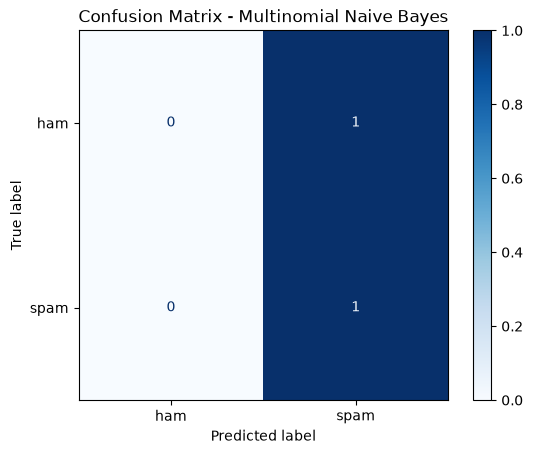

In [24]:
!pip install matplotlib


Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



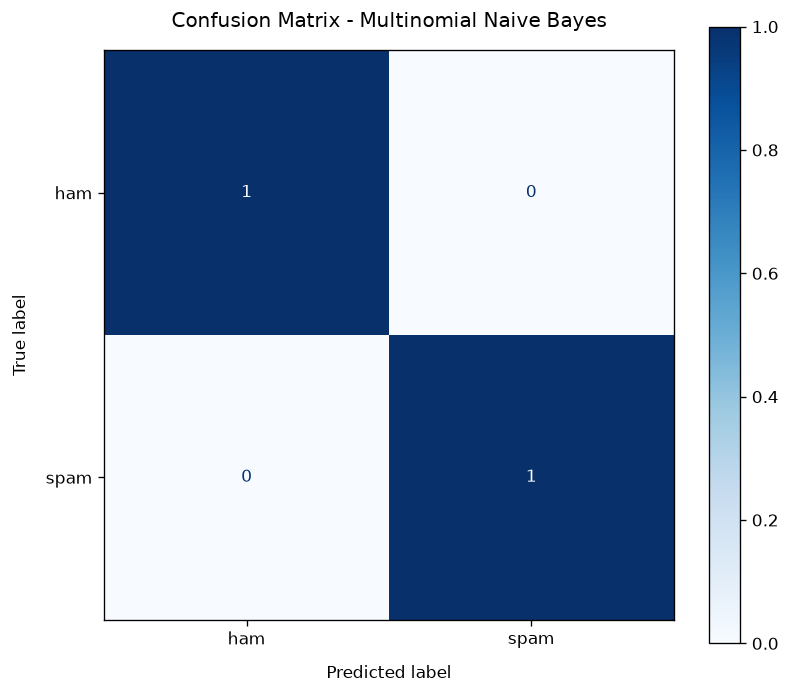

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

x_train, x_test, y_train, y_test = train_test_split(
    x,
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)
display.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=True
)
ax.set_title("Confusion Matrix - Multinomial Naive Bayes", pad=14)
ax.set_xlabel("Predicted label", labelpad=10)
ax.set_ylabel("True label", labelpad=10)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()